<a href="https://colab.research.google.com/github/VSahh/Data-analysis-for-product-store/blob/main/Data_analysis_for_product_store.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sqlite3
import seaborn as sns

# Connecting Google Drive
from google.colab import drive
drive.mount("/content/drive")
%cd /content/drive/MyDrive/colaboratory

events = pd.read_csv("events.csv")
countries = pd.read_csv("countries.csv")
products = pd.read_csv("products.csv")

countries = pd.DataFrame(countries)
events = pd.DataFrame(events)
products = pd.DataFrame(products)



Mounted at /content/drive
/content/drive/MyDrive/colaboratory


#Data cleaning

##Events

Events основна таблиця, яка містить в собі ключі для з`єднання:
- product_id з таблицею product;
- country_code з таблицею countries.

Типи даних в таблиці events підходять, окрім стовпців order_date та ship_date, які потрбіно буде перетворити в тип datetype. Назви стовпців потрібно перевести в стиль написання snake_case, перевірити пропущені значення в датасеті та зробити всі значення у стовпцях типу object з маленької літери і видалити пробіли.

In [ ]:
# Назви стовпців в стилі snake_case
events.columns = (events.columns.str.strip().str.lower().str.replace(" ","_"))

# Змінюєм тип дани у datetime
events['order_date']= pd.to_datetime(events['order_date'])
events['ship_date']= pd.to_datetime(events['ship_date'])

# Всі значення у стовпцях типу object з маленької літери
obj_cols = events.select_dtypes(include='object').columns
events[obj_cols] = events[obj_cols].apply(lambda col: col.str.lower().str.strip())

# events.head()
events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1330 entries, 0 to 1329
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   order_id        1330 non-null   int64         
 1   order_date      1330 non-null   datetime64[ns]
 2   ship_date       1330 non-null   datetime64[ns]
 3   order_priority  1330 non-null   object        
 4   country_code    1248 non-null   object        
 5   product_id      1330 non-null   int64         
 6   sales_channel   1330 non-null   object        
 7   units_sold      1328 non-null   float64       
 8   unit_price      1330 non-null   float64       
 9   unit_cost       1330 non-null   float64       
dtypes: datetime64[ns](2), float64(3), int64(2), object(3)
memory usage: 104.0+ KB


In [ ]:
# Відсоток пропущених значень у стовпцях досить значний, тому замінимо units_sold на медіану значення датасету, а country_code на unknown
print(events.isna().sum()/events.shape[0]*100)

order_id          0.000000
order_date        0.000000
ship_date         0.000000
order_priority    0.000000
country_code      6.165414
product_id        0.000000
sales_channel     0.000000
units_sold        0.150376
unit_price        0.000000
unit_cost         0.000000
dtype: float64


In [ ]:
# Пропущені значення заміняємо медіаною
events['units_sold'] = events['units_sold'].fillna(events['units_sold'].median())
# Пропущені значення заміняємо на unknown
events['country_code'] = events['country_code'].fillna('unknown')
# Дублікатів немає
double_events = events.duplicated().sum()


In [ ]:
# Аномалій не виявлено
events.describe()

,order_id,order_date,ship_date,product_id,units_sold,unit_price,unit_cost
count,1.330000e+03,1330,1330,1330.000000,1330.000000,1330.000000,1330.000000
mean,5.412048e+08,2013-10-12 06:09:12.180451072,2013-11-06 00:46:33.383458816,5788.096241,4952.216541,264.893541,187.246812
min,1.006406e+08,2010-01-01 00:00:00,2010-01-10 00:00:00,1270.000000,2.000000,9.330000,6.920000
25%,3.190004e+08,2011-12-16 06:00:00,2012-01-03 00:00:00,3127.000000,2360.750000,81.730000,35.840000
50%,5.387164e+08,2013-10-17 00:00:00,2013-11-09 00:00:00,5988.000000,4962.000000,154.060000,97.440000
75%,7.544628e+08,2015-08-28 18:00:00,2015-10-03 18:00:00,8681.000000,7458.750000,437.200000,263.330000
max,9.998797e+08,2017-07-23 00:00:00,2017-08-31 00:00:00,8969.000000,9999.000000,668.270000,524.960000
std,2.573882e+08,NaN,NaN,2820.728878,2903.012194,217.323460,176.158873


##Products

In [ ]:
# Назви стовпців в стилі snake_case
products.columns = (products.columns.str.strip().str.lower().str.replace(" ","_"))

# Всі значення у стовпцях типу object з маленької літери
obj_colss = products.select_dtypes(include='object').columns
products[obj_colss] = products[obj_colss].apply(lambda col: col.str.lower().str.strip())

# Дублікатів немає
double_products = products.duplicated().sum()

products.head(10)
# events.info()

,id,item_type
0,2103,cereal
1,7940,household
2,2455,clothes
3,1270,beverages
4,8681,office supplies
5,4594,fruits
6,5988,vegetables
7,7331,baby food
8,8875,meat
9,8293,cosmetics


##Countries

In [ ]:
# Назви стовпців в стилі snake_case
countries.columns = (countries.columns.str.strip().str.lower().str.replace("-","_"))

# Всі значення у стовпцях типу object з маленької літери
obj_colsss = countries.select_dtypes(include='object').columns
countries[obj_colsss] = countries[obj_colsss].apply(lambda col: col.str.lower().str.strip())

countries.head(10)
# events.info()

,name,alpha_2,alpha_3,region,sub_region
0,afghanistan,af,afg,asia,southern asia
1,åland islands,ax,ala,europe,northern europe
2,albania,al,alb,europe,southern europe
3,algeria,dz,dza,africa,northern africa
4,american samoa,as,asm,oceania,polynesia
5,andorra,ad,and,europe,southern europe
6,angola,ao,ago,africa,sub-saharan africa
7,anguilla,ai,aia,americas,latin america and the caribbean
8,antarctica,aq,ata,NaN,NaN
9,antigua and barbuda,ag,atg,americas,latin america and the caribbean


In [ ]:
# пропущене значення заміняємо відповідно до їх name
countries.isna().sum()/events.shape[0]*100
missed_values = countries[countries.isnull().any(axis=1)]
countries['alpha_2']=countries['alpha_2'].fillna("na")
countries[['region','sub_region']]=countries[['region','sub_region']].fillna("antarctica")

# Дублікатів немає
double_countries = countries.duplicated().sum()

countries.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 249 entries, 0 to 248
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   name        249 non-null    object
 1   alpha_2     249 non-null    object
 2   alpha_3     249 non-null    object
 3   region      249 non-null    object
 4   sub_region  249 non-null    object
dtypes: object(5)
memory usage: 9.9+ KB


#Data analysis and visualization

###Merge in one dataframe

In [ ]:
merged = events.merge(countries, left_on='country_code', right_on='alpha_3', how='left')
df = merged.merge(products, left_on='product_id', right_on='id')
# видалення дублюючих колонок
df = df.drop(columns=['id',"country_code"])
df = df.fillna('unknown')

# df.info()
df.head(20)




,order_id,order_date,ship_date,order_priority,product_id,sales_channel,units_sold,unit_price,unit_cost,name,alpha_2,alpha_3,region,sub_region,item_type
0,100640618,2014-10-08,2014-10-18,m,2103,online,650.0,205.70,117.11,norway,no,nor,europe,northern europe,cereal
1,100983083,2016-08-11,2016-08-11,c,2103,offline,1993.0,205.70,117.11,serbia,rs,srb,europe,southern europe,cereal
2,101025998,2014-07-18,2014-08-11,m,7940,online,4693.0,668.27,502.54,unknown,unknown,unknown,unknown,unknown,household
3,102230632,2017-05-13,2017-06-13,l,2455,online,1171.0,109.28,35.84,montenegro,me,mne,europe,southern europe,clothes
4,103435266,2012-08-11,2012-09-18,h,1270,offline,7648.0,47.45,31.79,serbia,rs,srb,europe,southern europe,beverages
5,103450715,2015-03-15,2015-04-18,h,8681,online,2220.0,651.21,524.96,slovakia,sk,svk,europe,eastern europe,office supplies
6,103499639,2013-04-20,2013-06-06,l,4594,online,6698.0,9.33,6.92,france,fr,fra,europe,western europe,fruits
7,103762280,2011-11-12,2011-12-14,m,5988,online,4419.0,154.06,90.93,spain,es,esp,europe,southern europe,vegetables
8,103832662,2012-09-19,2012-10-20,h,7331,offline,5247.0,255.28,159.42,croatia,hr,hrv,europe,southern europe,baby food
9,104008615,2011-01-23,2011-02-22,m,2103,online,7315.0,205.70,117.11,germany,de,deu,europe,western europe,cereal


###General metrics




In [ ]:

count_orders = df['order_id'].count()

df["revenue"] =df['units_sold']*df['unit_price']
total_revenue = df['revenue'].sum()

df["profit"] = df['revenue']-df['units_sold']*df['unit_cost']
total_profit = df['profit'].sum()

df["cost"] = df['units_sold']*df['unit_cost']
total_cost = df["cost"].sum()

unique_country = df['name'].nunique()

item_type = df['item_type'].value_counts()

print(f"Count orders: {count_orders}\n\nTotal revenue:{total_revenue}\n\nTotal profit:{total_profit}\n\nTotal cost:{total_cost}\n\nCount unique_country:{unique_country}\nCategory product:{item_type.index}")

Count orders: 1330

Total revenue:1704628370.65

Total profit:501842633.11999995

Total cost:1202785737.5299997

Count unique_country:46
Category product:Index(['office supplies', 'beverages', 'personal care', 'cosmetics',
       'vegetables', 'baby food', 'fruits', 'meat', 'clothes', 'cereal',
       'snacks', 'household'],
      dtype='object', name='item_type')


Count orders: 1330

Total revenue: 1704628370.65

Total profit: 501842633.11999995

Total cost: 1202785737.5299997

Count unique_country: 46

Category product:
- office supplies
- beverages
- personal care
- cosmetics
- vegetables
- baby food
- fruits
- meat
- clothes
- cereal
- snacks
- household

##Sales analysis

###Analysis by category

Revenue by category

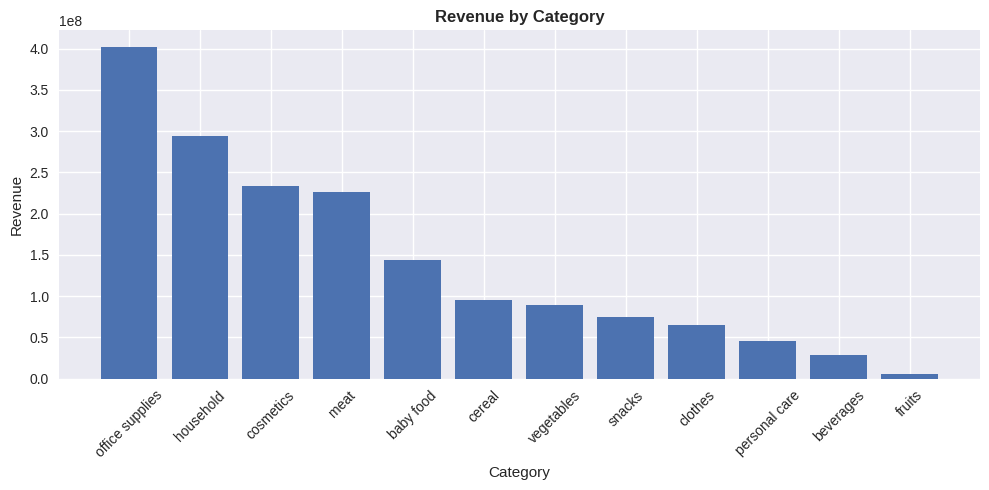

In [ ]:
revenue_by_category = df.groupby(["item_type"])['revenue'].sum().sort_values(ascending=False)

plt.style.use("seaborn-v0_8")
plt.figure(figsize=(10,5))
plt.bar(revenue_by_category.index, revenue_by_category.values)
plt.xlabel('Category')
plt.ylabel('Revenue')
plt.title('Revenue by Category', fontweight="bold")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Cost by Category

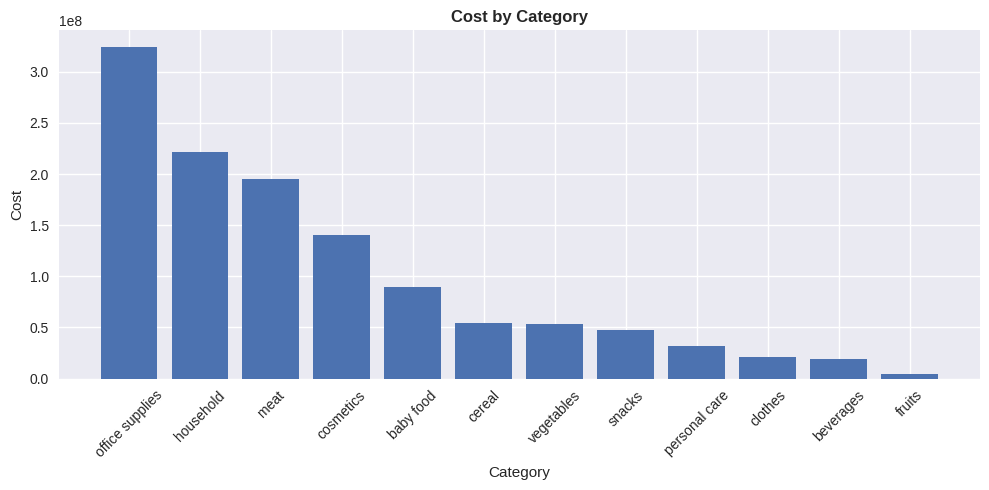

In [ ]:
cost_by_category = df.groupby(["item_type"])['cost'].sum().sort_values(ascending=False)

plt.style.use("seaborn-v0_8")
plt.figure(figsize=(10,5))
plt.bar(cost_by_category.index, cost_by_category.values)
plt.xlabel('Category')
plt.ylabel('Cost')
plt.title('Cost by Category', fontweight="bold")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Profit by Category

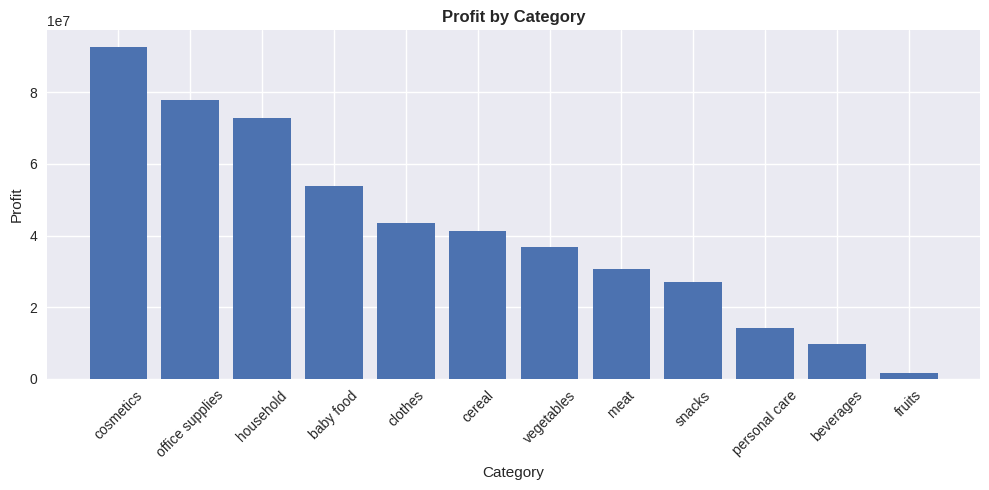

In [ ]:
profit_by_category = df.groupby(["item_type"])['profit'].sum().sort_values(ascending=False)

plt.style.use("seaborn-v0_8")
plt.figure(figsize=(10,5))
plt.bar(profit_by_category.index, profit_by_category.values)
plt.xlabel('Category')
plt.ylabel('Profit')
plt.title('Profit by Category', fontweight="bold")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Product popularity by category

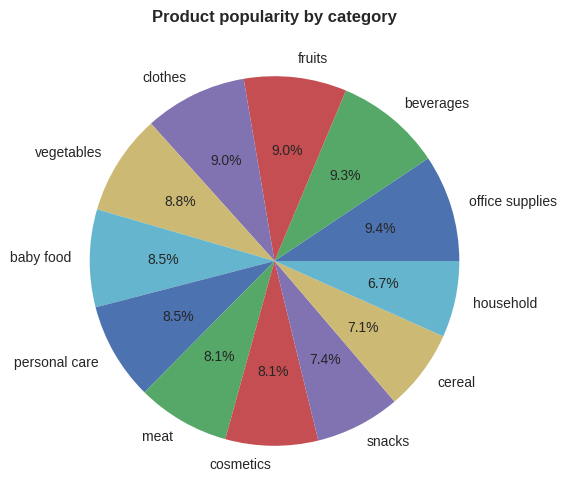

In [ ]:
product_popularity_by_category = df.groupby(["item_type"])['units_sold'].sum().sort_values(ascending=False)

plt.style.use("seaborn-v0_8")
plt.figure(figsize=(8, 6))
plt.pie(x=product_popularity_by_category.head(12), labels=product_popularity_by_category.head(12).index, autopct='%1.1f%%')
plt.title('Product popularity by category', fontweight="bold")
plt.show()

Аналізуючи графіки продажей по категоріях, приходимо до висновку що основими лідерами є категорії:
- office suplplies;
- household;
- cosmetics

Вони знаходяться в топі як по revenue так і по profit. Увагу потрібно звернути на категорію cosmetics, так як в ній найменші затрати на товари, але найбільший profit, хоча по популярності вона не знаходиться в топі продаж. Якщо підняти популярність цієї категорії, то можна значно наростити profit.

Аутсайдерами є категорії:
- fruits;
- beverages

Категорія fruits приносить дуже мало профіту, її можна виключити з продаж, щоб уникнути операційного навантаження. Категорія beverages по популярності знаходиться на 2 місці, що свідчить про високу увагу до категорії, але профіт з категорії малий, можна проексперментувати з збільшенням цін на продукти, або зменшити cost для ефективніших продаж.

###Analysis by geography

Revenue by Country

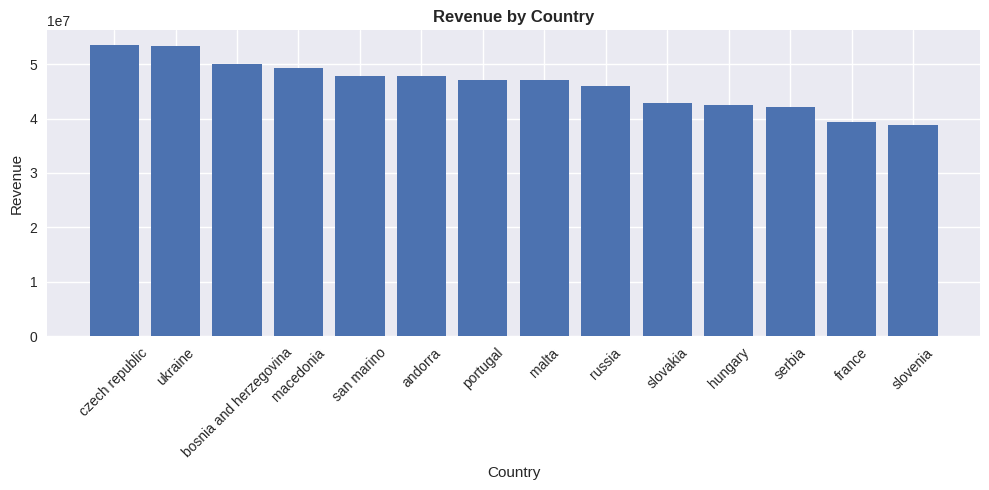

In [ ]:
revenue_by_country = df.groupby(["name"])['revenue'].sum().sort_values(ascending=False)

plt.style.use("seaborn-v0_8")
plt.figure(figsize=(10,5))
plt.bar(revenue_by_country.iloc[1:15].index, revenue_by_country.iloc[1:15].values)
plt.xlabel('Country')
plt.ylabel('Revenue')
plt.title('Revenue by Country', fontweight="bold")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Profit by Country

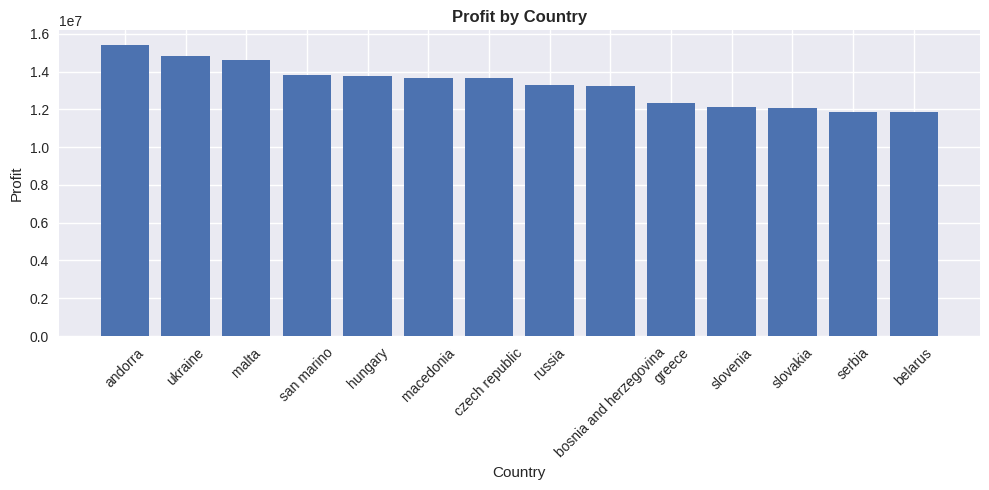

In [ ]:
profit_by_country = df.groupby(["name"])['profit'].sum().sort_values(ascending=False)

plt.style.use("seaborn-v0_8")
plt.figure(figsize=(10,5))
plt.bar(profit_by_country.iloc[1:15].index, profit_by_country.iloc[1:15].values)
plt.xlabel('Country')
plt.ylabel('Profit')
plt.title('Profit by Country', fontweight="bold")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Product popularity by country

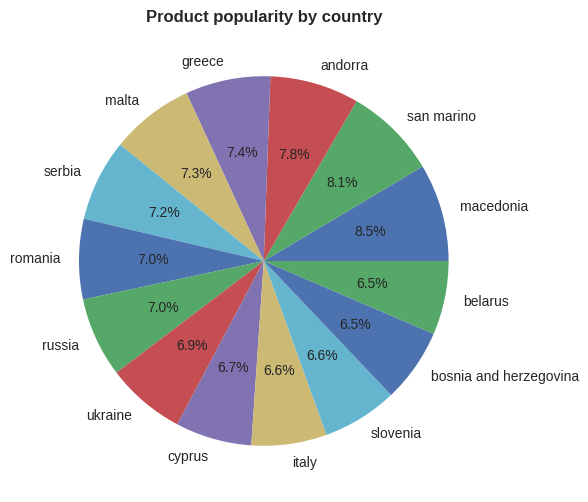

In [ ]:
product_popularity_by_country = df.groupby(["name"])['units_sold'].sum().sort_values(ascending=False)

plt.style.use("seaborn-v0_8")
plt.figure(figsize=(8, 6))
plt.pie(x=product_popularity_by_country.iloc[1:15], labels=product_popularity_by_country.iloc[1:15].index, autopct='%1.1f%%')
plt.title('Product popularity by country', fontweight="bold")
plt.show()

Profit by region

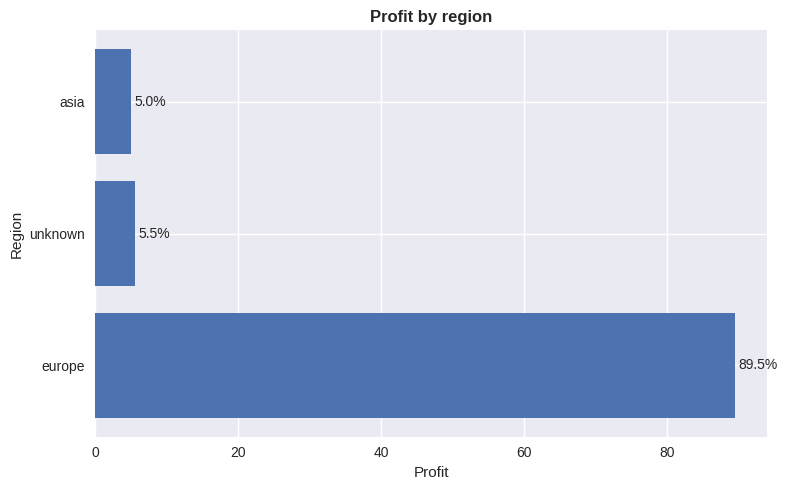

In [ ]:
profit_by_country = df.groupby(["region"])['profit'].sum()
profit_by_country = profit_by_country / profit_by_country.sum() * 100
profit_by_country = profit_by_country.sort_values(ascending=False)

plt.style.use("seaborn-v0_8")
plt.figure(figsize=(8,5))
plt.barh(profit_by_country.index, profit_by_country.values )
for i, v in enumerate(profit_by_country.values):
    plt.text(v + 0.5, i, f"{v:.1f}%", va='center', ha='left')
plt.xlabel('Profit')
plt.ylabel('Region')
plt.title('Profit by region', fontweight="bold")
plt.tight_layout()
plt.show()

Revenue by region

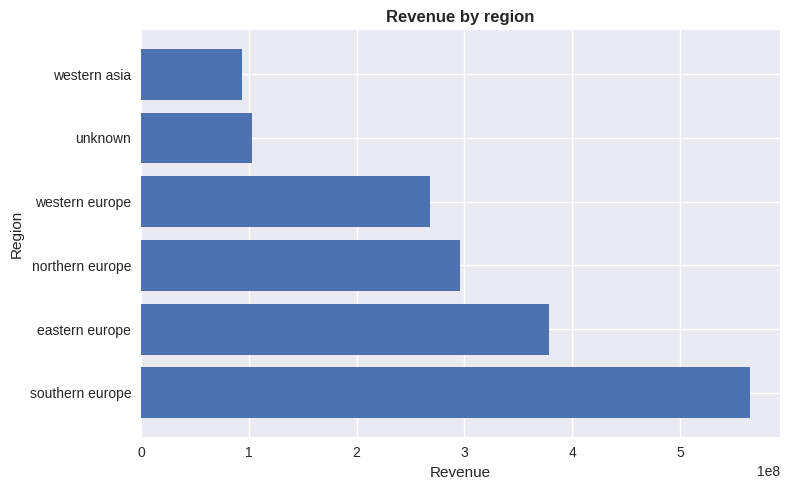

In [ ]:
sub_region_data = df.groupby("sub_region")["revenue"].sum().sort_values(ascending=False)

plt.style.use("seaborn-v0_8")
plt.figure(figsize=(8,5))
plt.barh(sub_region_data.index, sub_region_data.values)
plt.xlabel('Revenue')
plt.ylabel('Region')
plt.title('Revenue by region', fontweight="bold")
plt.tight_layout()
plt.show()


Якщо дивитись на продажі в розрізі географії, то 89,5% профіту принесли продажі в Europe , в той час як в Asia — 5,0%. Топ 3 країни по profit є:
- Andora;
- Ukraine;
- Malta

У розрізі субрегіонів домінує Southern Europe, за якою йде Eastern Europe.

###Analysis by sales channel

Revenue by Category and Channel

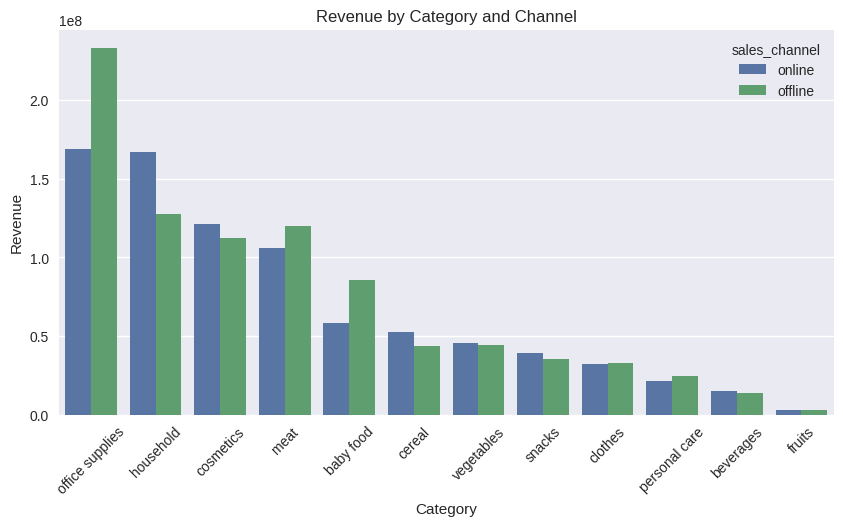

In [ ]:
order_rev = df.groupby("item_type")["revenue"].sum().sort_values(ascending=False).index

plt.figure(figsize=(10, 5))
plt.style.use("seaborn-v0_8")
sns.barplot(data=df, x="item_type", y="revenue", errorbar=("ci", False), estimator=np.sum, order=order_rev, hue="sales_channel")
plt.xlabel("Category")
plt.ylabel("Revenue")
plt.title("Revenue by Category and Channel")
plt.xticks(rotation=45)
plt.show()

Profit by Category and Channel

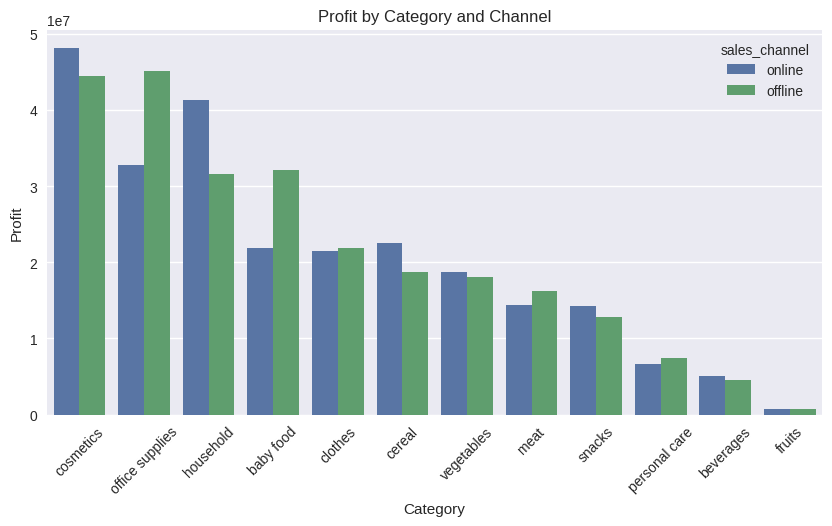

In [ ]:
order_rev = df.groupby("item_type")["profit"].sum().sort_values(ascending=False).index

plt.figure(figsize=(10, 5))
plt.style.use("seaborn-v0_8")
sns.barplot(data=df, x="item_type", y="profit", errorbar=("ci", False), estimator=np.sum, order=order_rev, hue="sales_channel")
plt.xlabel("Category")
plt.ylabel("Profit")
plt.title("Profit by Category and Channel")
plt.xticks(rotation=45)
plt.show()

Product popularity by channel

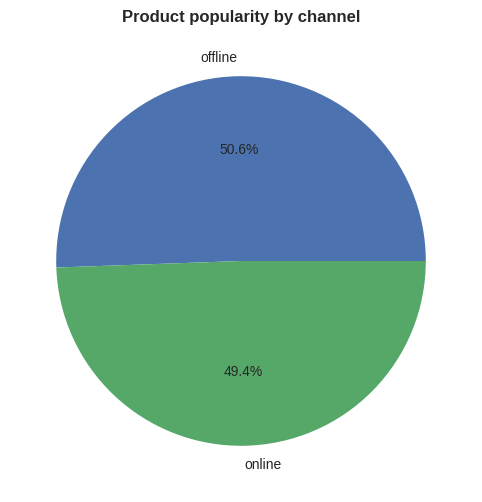

In [ ]:
product_popularity_by_channel = df.groupby(["sales_channel"])['units_sold'].sum().sort_values(ascending=False)

plt.style.use("seaborn-v0_8")
plt.figure(figsize=(8, 6))
plt.pie(x=product_popularity_by_channel, labels=product_popularity_by_channel.index, autopct='%1.1f%%')
plt.title('Product popularity by channel', fontweight="bold")
plt.show()

Кількість продажів рівномірно розподілена на Online — 49,4% та Offline — 50,6%. Значних перекосів по категоріях немає, окрім незначного перекосу в категорії  office supplies в сторону offline.

###Analysis by delivery time

Delivery time by category

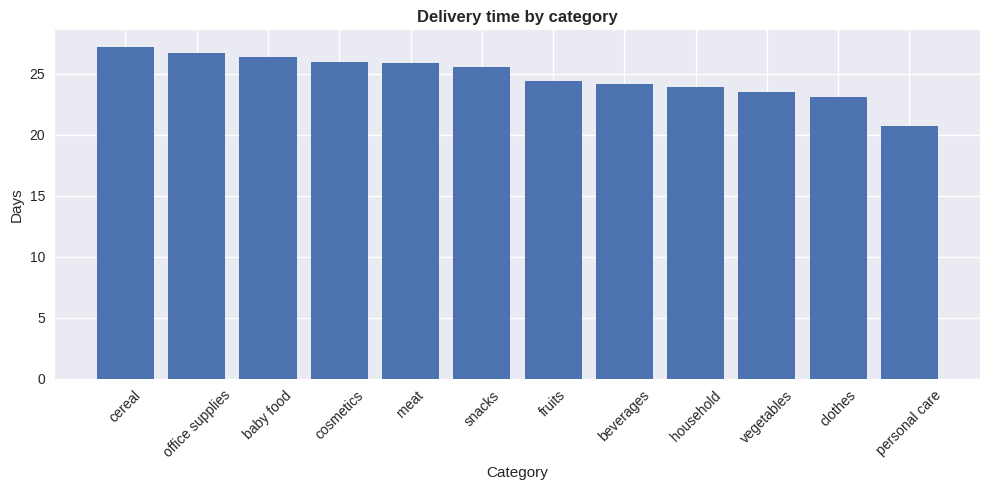

In [ ]:
df["delivery_time"] = df['ship_date']-df['order_date']
df["delivery_time"] = df["delivery_time"].dt.total_seconds() / 86400

delivery = df.groupby(["item_type"])['delivery_time'].mean().sort_values(ascending=False)


plt.style.use("seaborn-v0_8")
plt.figure(figsize=(10,5))
plt.bar(delivery.index, delivery.values)
plt.xlabel('Category')
plt.ylabel('Days')
plt.title('Delivery time by category', fontweight="bold")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Delivery time by country

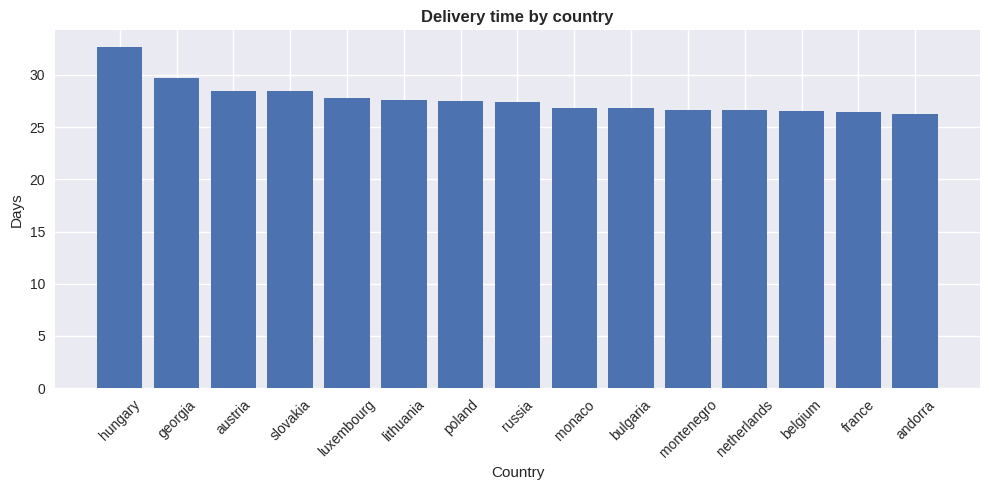

In [ ]:
delivery_country = df.groupby(["name"])['delivery_time'].mean().sort_values(ascending=False)


plt.style.use("seaborn-v0_8")
plt.figure(figsize=(10,5))
plt.bar(delivery_country.iloc[0:15].index, delivery_country.iloc[0:15].values)
plt.xlabel('Country')
plt.ylabel('Days')
plt.title('Delivery time by country', fontweight="bold")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Delivery time by region

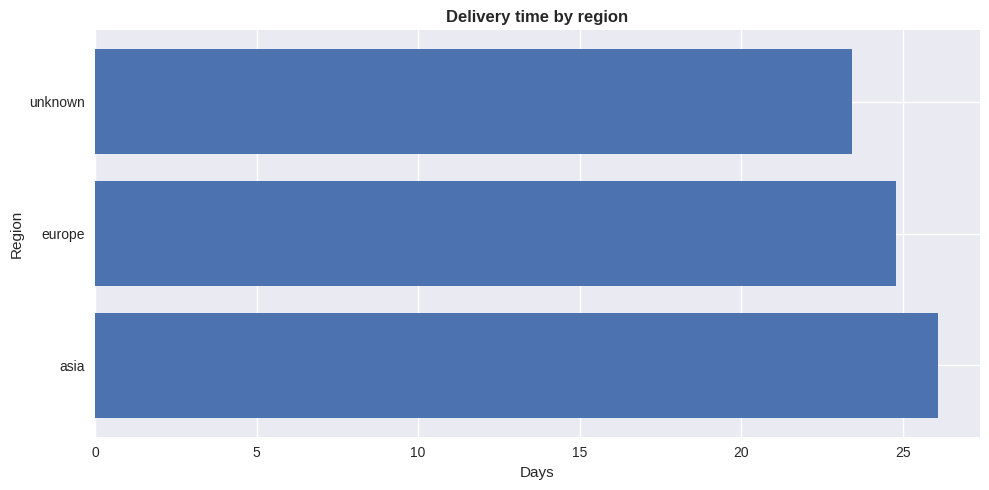

In [ ]:
delivery_region = df.groupby(["region"])['delivery_time'].mean().sort_values(ascending=False)


plt.style.use("seaborn-v0_8")
plt.figure(figsize=(10,5))
plt.barh(delivery_region.index, delivery_region.values)
plt.xlabel('Days')
plt.ylabel('Region')
plt.title('Delivery time by region', fontweight="bold")

plt.tight_layout()
plt.show()

Profit by delivery time

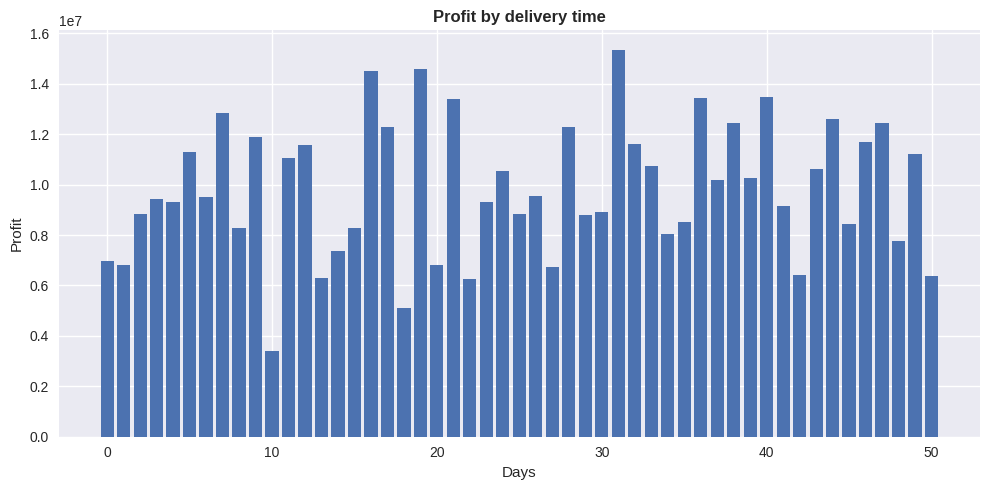

In [ ]:
delivery_profit = df.groupby(["delivery_time"])['profit'].sum().sort_values(ascending=False)


plt.style.use("seaborn-v0_8")
plt.figure(figsize=(10,5))
plt.bar(delivery_profit.index, delivery_profit.values)
plt.xlabel('Days')
plt.ylabel('Profit')
plt.title('Profit by delivery time', fontweight="bold")
plt.tight_layout()
plt.show()

Чіткої залежності між часом доставки та прибутком не виявлено. У більшості країн час обробки стабільний, тільки Hungary виділяється з списку, що може свідчити про проблеми з обробкою або доставкою товарів у цій країні. Залежності profit від часу доставки не спостерігаєтся.


###Dynamic by date

Revenue by mounth

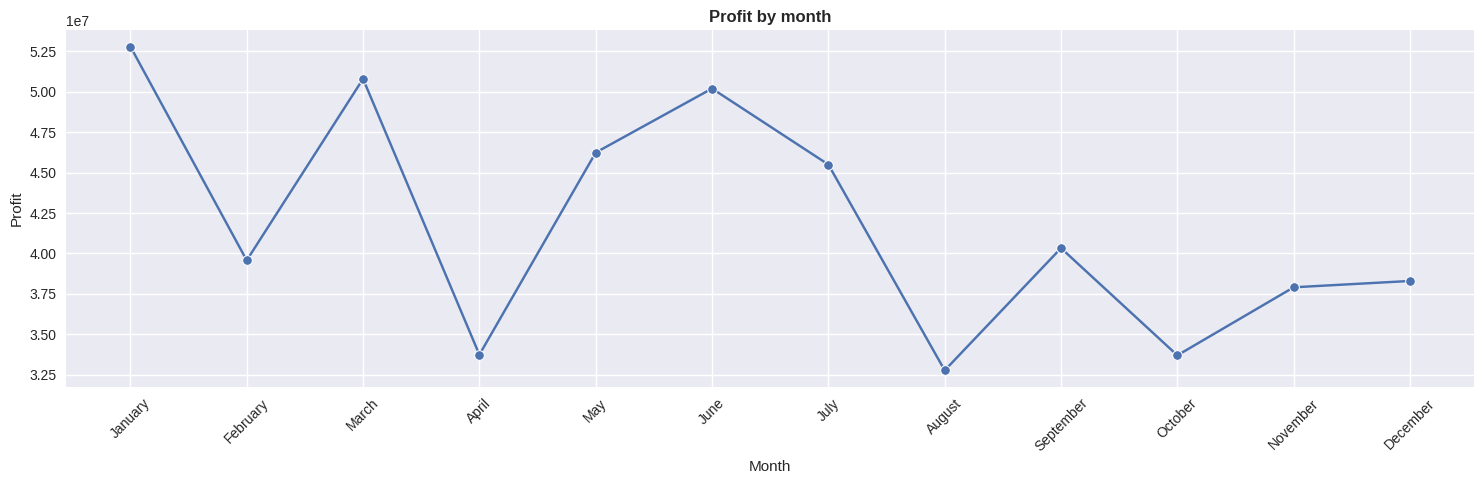

In [ ]:

df["month"] = df["order_date"].dt.month
df["month_sales"] = df['order_date'].dt.month_name()
sales_dynamic_month= df.groupby(["month","month_sales"])["profit"].sum().reset_index().sort_values('month')

plt.style.use("seaborn-v0_8")
plt.figure(figsize=(15,5))
sns.lineplot(
    data=sales_dynamic_month,
    x="month_sales",
    y="profit",
    marker="o")
plt.xlabel('Month')
plt.ylabel('Profit')
plt.title('Profit by month', fontweight="bold")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Revenue by year

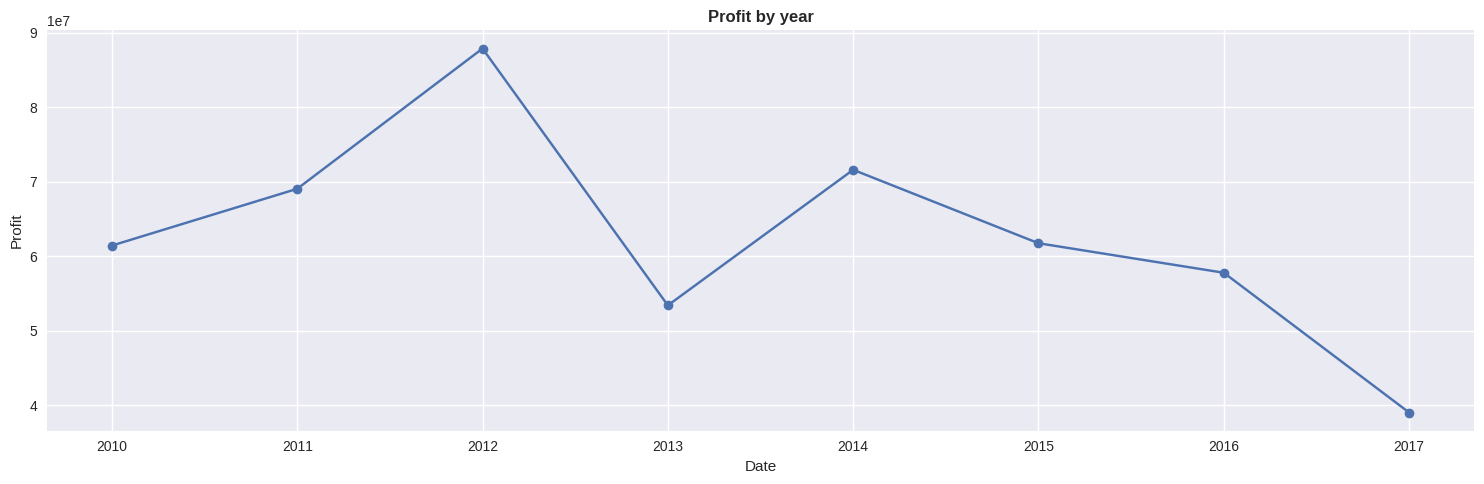

In [ ]:
df["year_sales"] = df['order_date'].dt.to_period("Y")
sales_dynamic_year= df.groupby("year_sales")["profit"].sum()

plt.style.use("seaborn-v0_8")
plt.figure(figsize=(15,5))
plt.plot(sales_dynamic_year.index.astype(str), sales_dynamic_year.values, marker="o")
plt.xlabel('Date')
plt.ylabel('Profit')
plt.title('Profit by year', fontweight="bold")
plt.tight_layout()
plt.show()

Profit dynamic by month and category

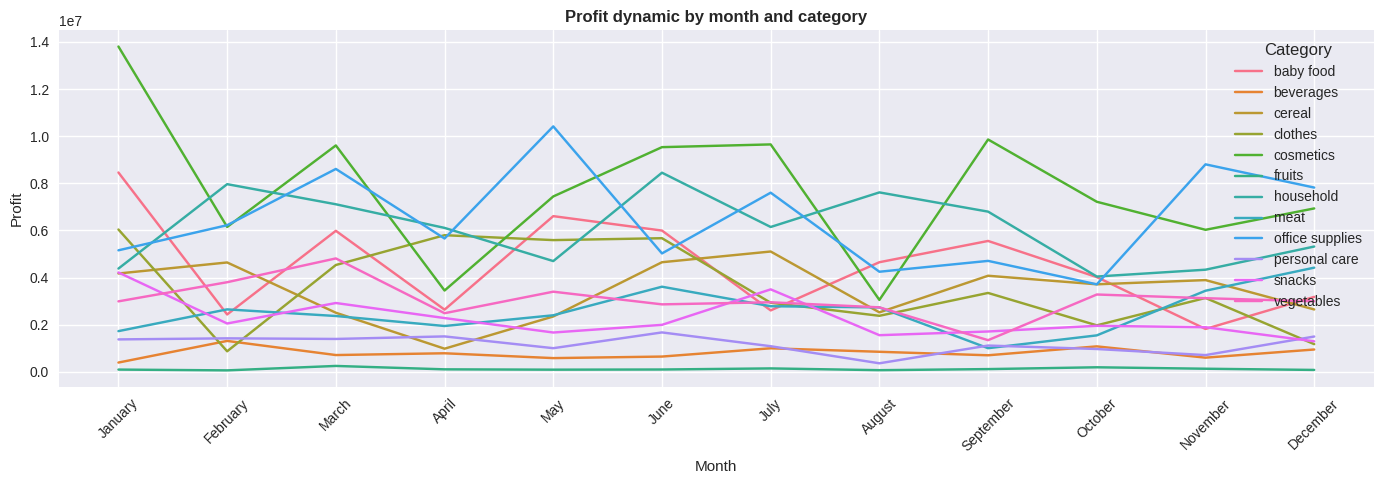

In [ ]:
sales_pivot = df.groupby(["month","month_sales", "item_type"])["profit"].sum().reset_index().sort_values('month')
plt.style.use("seaborn-v0_8")
plt.figure(figsize=(14,5))
sns.lineplot(data=sales_pivot, x="month_sales", y="profit", hue="item_type")
plt.xlabel('Month')
plt.ylabel('Profit')
plt.title('Profit dynamic by month and category', fontweight="bold")
plt.legend(title="Category")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

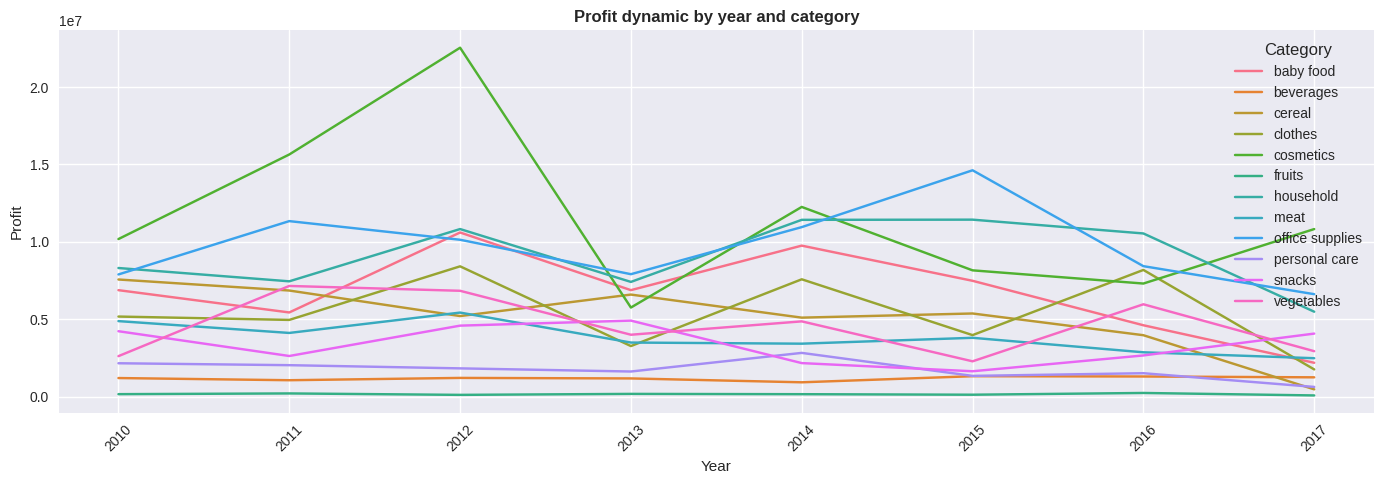

In [ ]:
sales_by_year_cat = df.groupby(["year_sales", "item_type"])["profit"].sum().reset_index()
sales_by_year_cat['year_sales']= sales_by_year_cat['year_sales'].astype(str)
plt.style.use("seaborn-v0_8")
plt.figure(figsize=(14,5))
sns.lineplot(data=sales_by_year_cat, x="year_sales", y="profit", hue="item_type")
plt.xlabel('Year')
plt.ylabel('Profit')
plt.title('Profit dynamic by year and category', fontweight="bold")
plt.legend(title="Category")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Profit dynamic by month and country

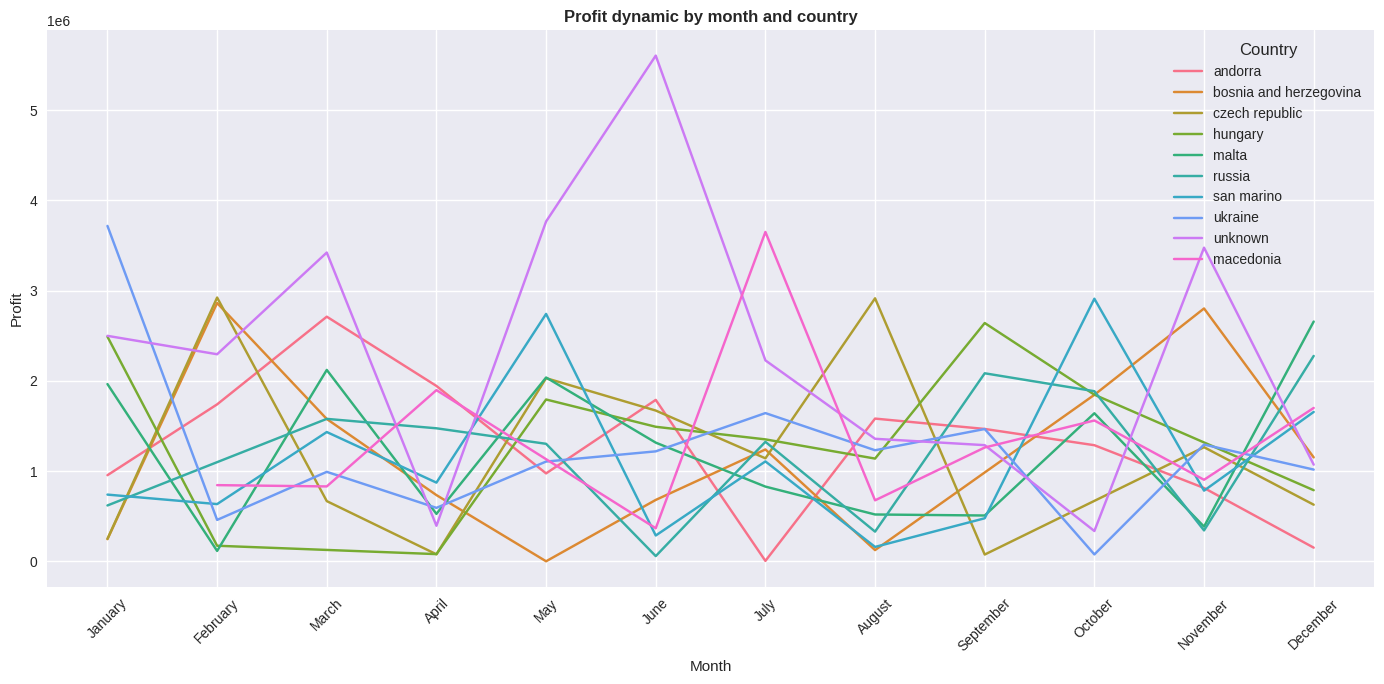

In [ ]:
top_10 = df.groupby('name')['profit'].sum().sort_values(ascending=False).head(10).index

sales_top10 = df[(df["name"].isin(top_10))]
sales_top10 = sales_top10.groupby(["month", "month_sales", "name"])["profit"].sum().reset_index().sort_values('month')
sales_top10["month_sales"] = sales_top10["month_sales"].astype(str)

plt.style.use("seaborn-v0_8")
plt.figure(figsize=(14,7))
sns.lineplot(data=sales_top10, x="month_sales", y="profit", hue="name", errorbar=None)
plt.xlabel('Month')
plt.ylabel('Profit')
plt.title('Profit dynamic by month and country', fontweight="bold")
plt.legend(title="Country")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


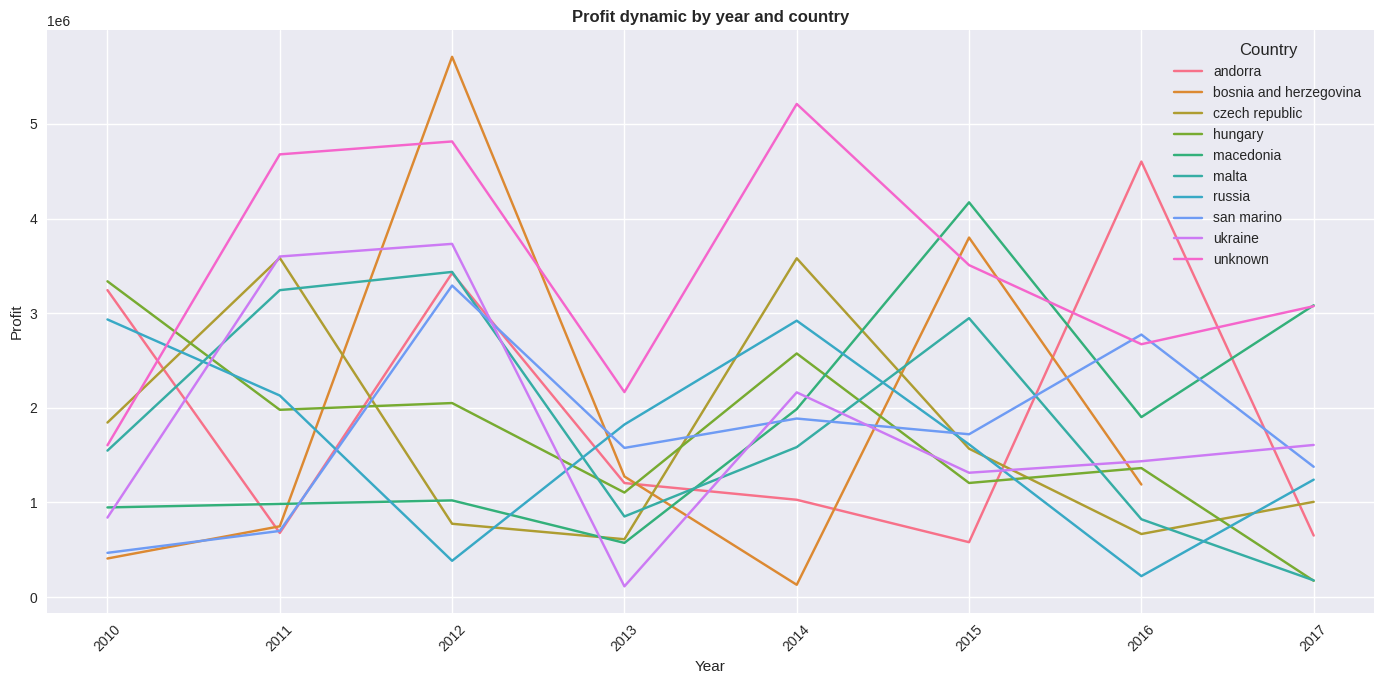

In [ ]:
top_10 = df.groupby('name')['profit'].sum().sort_values(ascending=False).head(10).index

sales_year_country = df[(df["name"].isin(top_10))]
sales_year_country = sales_year_country.groupby(["year_sales", "name"])["profit"].sum().reset_index()
sales_year_country["year_sales"] = sales_year_country["year_sales"].astype(str)

plt.style.use("seaborn-v0_8")
plt.figure(figsize=(14,7))
sns.lineplot(data=sales_year_country, x="year_sales", y="profit", hue="name", errorbar=None)
plt.xlabel('Year')
plt.ylabel('Profit')
plt.title('Profit dynamic by year and country', fontweight="bold")
plt.legend(title="Country")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Profit dynamic by month and region

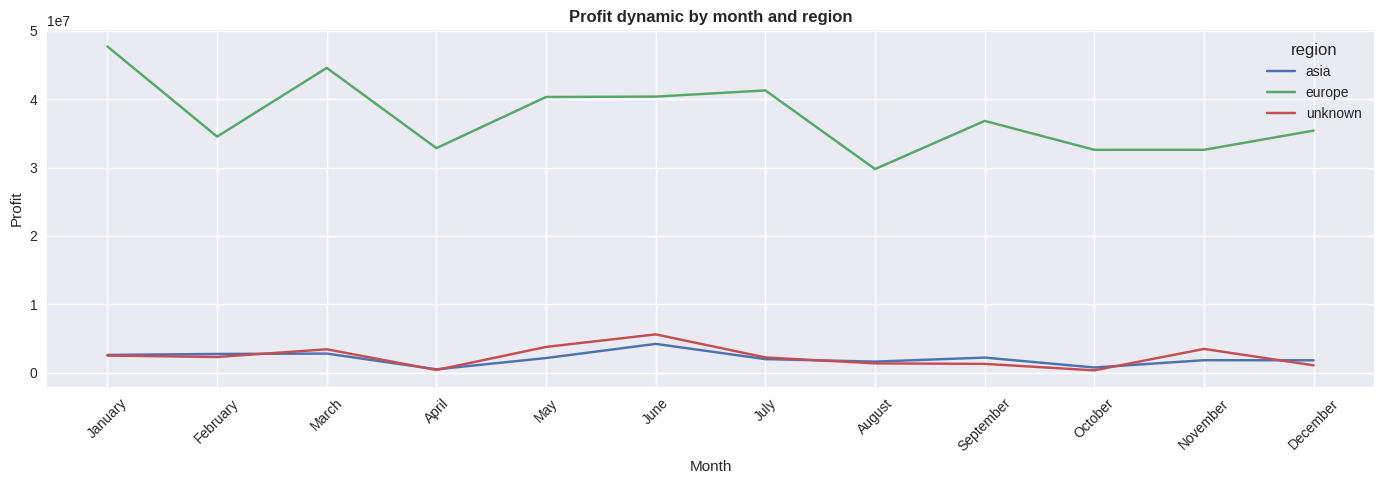

In [ ]:
sales_region = df.groupby(["month","month_sales", "region"])["profit"].sum().reset_index().sort_values("month")
sales_region["month_sales"] = sales_region["month_sales"].astype(str)


plt.style.use("seaborn-v0_8")
plt.figure(figsize=(14,5))
sns.lineplot(data=sales_region, x="month_sales", y="profit", hue="region",  errorbar=None)
plt.xlabel('Month')
plt.ylabel('Profit')
plt.title('Profit dynamic by month and region', fontweight="bold")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Profit dynamic by year and region

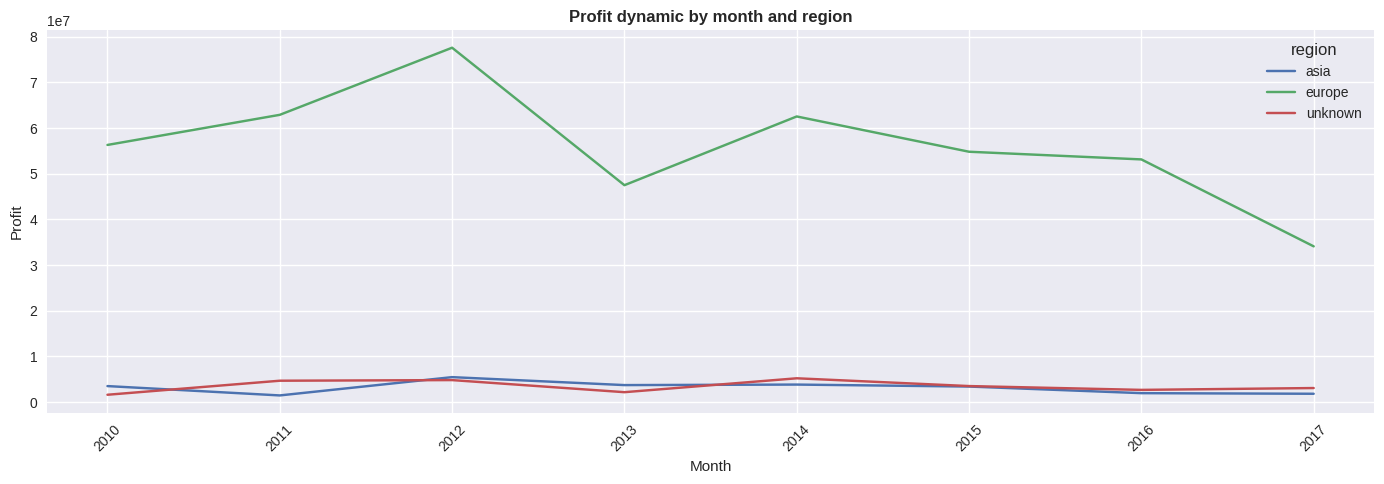

In [ ]:
sales_region_year = df.groupby(["year_sales", "region"])["profit"].sum().reset_index()
sales_region_year ["year_sales"] = sales_region_year ["year_sales"].astype(str)

plt.style.use("seaborn-v0_8")
plt.figure(figsize=(14,5))
sns.lineplot(data=sales_region_year , x="year_sales", y="profit", hue="region",  errorbar=None)
plt.xlabel('Year')
plt.ylabel('Profit')
plt.title('Profit dynamic by year and region', fontweight="bold")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Profit by days and category

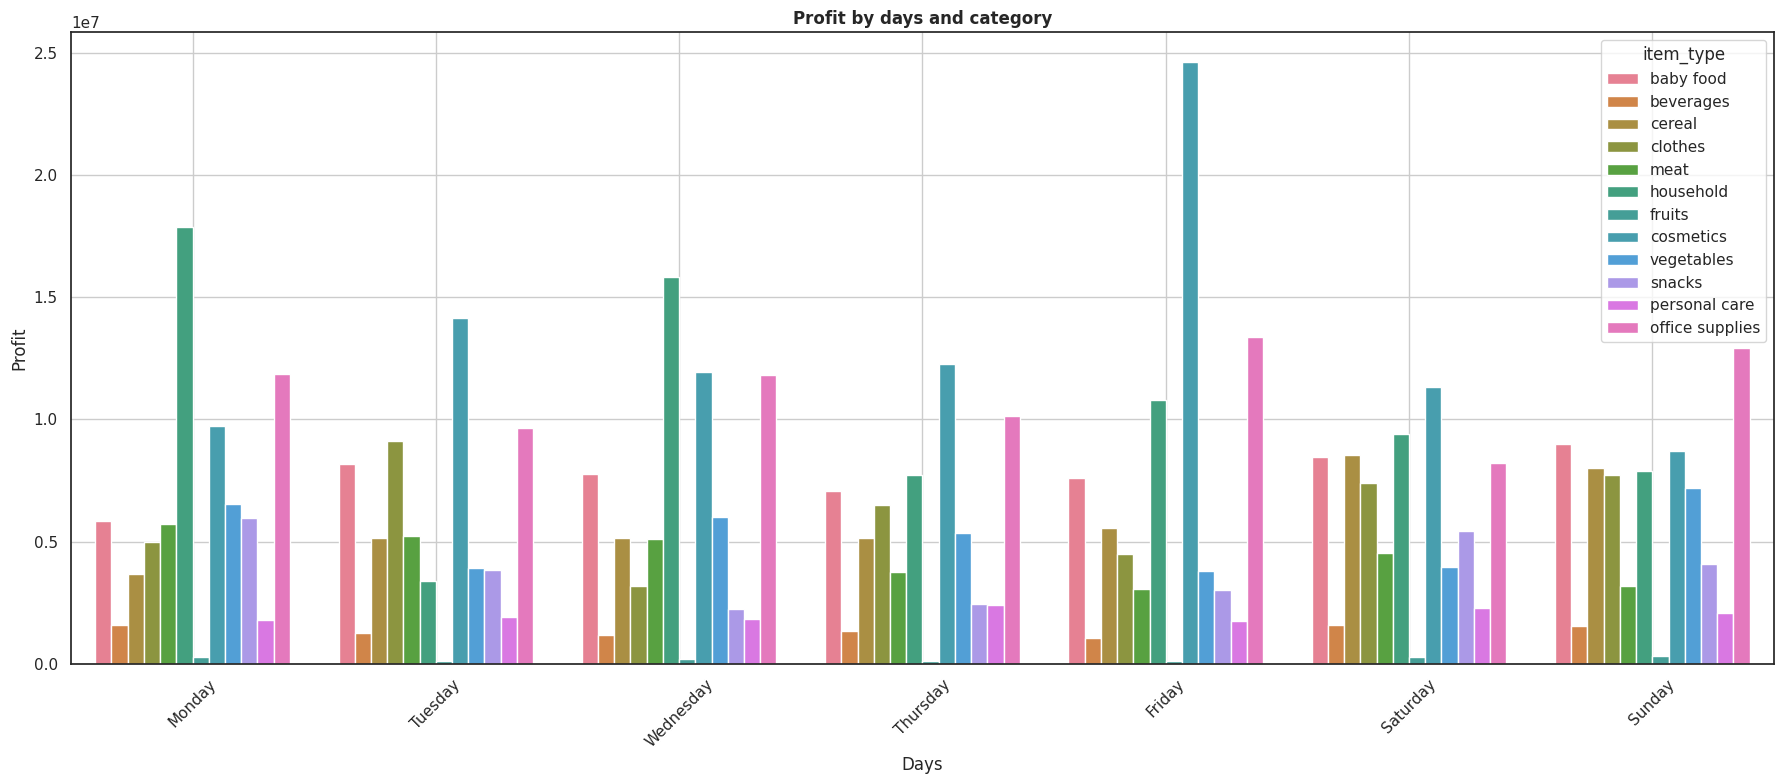

In [ ]:
df['day_of_week'] = df['order_date'].dt.day_name()
sales_by_day = df.groupby(['day_of_week', "item_type"])['profit'].sum().reset_index()
day_order = {
    "Monday": 1,
    "Tuesday": 2,
    "Wednesday": 3,
    "Thursday": 4,
    "Friday": 5,
    "Saturday": 6,
    "Sunday": 7
    }
sales_by_day["day_number"] = sales_by_day["day_of_week"].map(day_order)
sales_by_day = sales_by_day.sort_values(by="day_number")


plt.style.use("default")
sns.set_theme(style="white")
plt.figure(figsize=(18,8))
sns.barplot(data=sales_by_day, x='day_of_week', y="profit", errorbar=(None),  hue="item_type")
# plt.bar(sales_by_day['day_of_week'], sales_by_day['revenue'])
plt.xlabel('Days')
plt.ylabel("Profit")
plt.title('Profit by days and category', fontweight="bold")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()


Profit by Day of Week

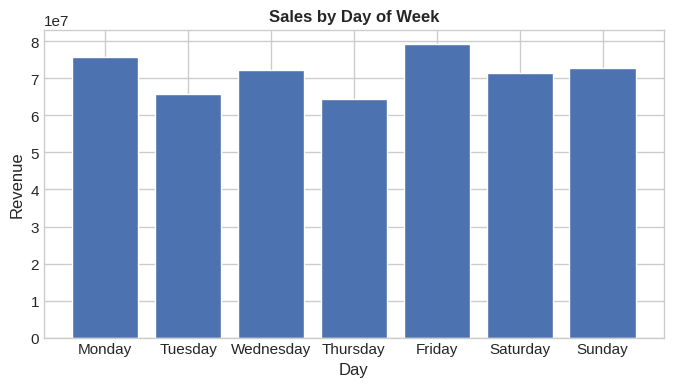

In [ ]:
day_week = df.groupby('day_of_week')['profit'].sum().reset_index()
day_order = {
    "Monday": 1,
    "Tuesday": 2,
    "Wednesday": 3,
    "Thursday": 4,
    "Friday": 5,
    "Saturday": 6,
    "Sunday": 7
    }
day_week["day_number"] = day_week["day_of_week"].map(day_order)
day_week= day_week.sort_values(by="day_number")

plt.figure(figsize=(8, 4))
plt.style.use("seaborn-v0_8-whitegrid")

plt.bar(day_week["day_of_week"], day_week["profit"])
plt.xlabel("Day")
plt.ylabel("Profit")
plt.title("Profit by Day of Week", fontweight="bold")
plt.show()

Графіки вказують нам на те, що прибуток демонстрував швидке зростання до  2012 року, а після 2012 року спостерігається стійкий спад прибутку і 2017 рік став найменш прибутковим в історії. Також з графіків видно що найбільшим драйвером є категорія Cosmetics, яка стабільно в топі по профіту між категоріями, потрібно зберігати фокус на цій категорії. По місяцях значного перекосу немає, але помітно що Січень та Березень є більш активним місяцем, що ймовірно пов’язано зі святковими періодами. Динаміка продажей протягом тижня без значних перекосів.

#Загальні метрики:
Count orders: 1330

Total revenue: 1704628370.65

Total profit: 501842633.11999995

Total cost: 1202785737.5299997

Count unique_country: 46

Category product:

- office supplies
- beverages
- personal care
- cosmetics
- vegetables
- baby food
- fruits
- meat
- clothes
- cereal
- snacks
- household

#Аналіз метрик по категоріях
Аналізуючи графіки продажей по категоріях, приходимо до висновку що основими лідерами є категорії:
- office suplplies;
- household;
- cosmetics

Вони знаходяться в топі як по revenue так і по profit. Увагу потрібно звернути на категорію cosmetics, так як в ній найменші затрати на товари, але найбільший profit, хоча по популярності вона не знаходиться в топі продаж. Якщо підняти популярність цієї категорії, то можна значно наростити profit.

Аутсайдерами є категорії:
- fruits;
- beverages

Категорія fruits приносить дуже мало профіту, її можна виключити з продаж, щоб уникнути операційного навантаження. Категорія beverages по популярності знаходиться на 2 місці, що свідчить про високу увагу до категорії, але профіт з категорії малий, можна проексперментувати з збільшенням цін на продукти, або зменшити cost для ефективніших продаж.

#Аналіз метрик в розрізі географічного розташування
Якщо дивитись на продажі в розрізі географії, то 89,5% профіту принесли продажі в Europe , в той час як в Asia — 5,0%. Топ 3 країни по profit є:
- Andora;
- Ukraine;
- Malta

У розрізі субрегіонів домінує Southern Europe, за якою йде Eastern Europe.

#Канали продажу: Online vs Offline
Кількість продажів рівномірно розподілена на Online — 49,4% та Offline — 50,6%. Значних перекосів по категоріях немає, окрім незначного перекосу в категорії  office supplies в сторону offline.

#Аналіз впливу часу доставки замовлення
Чіткої залежності між часом доставки та прибутком не виявлено. У більшості країн час обробки стабільний, тільки Hungary виділяється з списку, що може свідчити про проблеми з обробкою або доставкою товарів у цій країні. Залежності profit від часу доставки не спостерігаєтся.

#Динаміка продажів
Графіки вказують нам на те, що прибуток демонстрував швидке зростання до  2012 року, а після 2012 року спостерігається стійкий спад прибутку і 2017 рік став найменш прибутковим в історії. Також з графіків видно що найбільшим драйвером є категорія Cosmetics, яка стабільно в топі по профіту між категоріями, потрібно зберігати фокус на цій категорії. По місяцях значного перекосу немає, але помітно що January та March є більш активним місяцем, що ймовірно пов’язано зі святковими періодами. Динаміка продажей протягом тижня без значних перекосів.